In [1]:
include("BarrierSynthesis.jl")
# include("PlotBarriers.jl")

compute_next_level_barriersPM (generic function with 1 method)

In [ ]:
@polyvar u[1:1]
@polyvar(x[1:4]) # x[1] is x, x[2] is y, x[3] is θ, x[4] is error
v = 0.9
    dynamics = [
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(-2.0/π)*(x[3]+π)-0.2x[4], ctrl[1], 0.]),
        (ctrl -> [v*(2.0/π)*(x[3] + π/2.0)-0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(2.0/π)*x[3]+0.2x[4], ctrl[1], 0]),
        (ctrl -> [v*(-2.0/π)*(x[3] - π/2.0)+0.2x[4],v*(-2.0/π)*(x[3]-π)-0.2x[4], ctrl[1], 0]),
    ]
g = 0.5^2 - x[1]^2 - x[2]^2 # Obstacle: is a (x,y) ball of radius 0.1 around origin
bounds = [[-10., 10.], [-10., 10.], [-π,π], [-1.,1.]]

4-element Vector{Vector{Float64}}:
 [-10.0, 10.0]
 [-10.0, 10.0]
 [-3.141592653589793, 3.141592653589793]
 [-1.0, 1.0]

In [ ]:
K = 1.0
δ = 1.0
τ = 0.12
ϵ = 0.1
α = 1e-3
max_degree=4
# Synthesis control set should match simulation actuation limits.
U = [[-7.0], [7.0]]
n_tests = 100

100

In [4]:
test_pts = [ get_random(bounds, g) for _ in 1:n_tests]

100-element Vector{Vector{Float64}}:
 [0.981243748265479, -5.73509943079535, -2.4080408398808815, 0.487957577357625]
 [2.539366623912711, -1.3176581075897058, 0.9396334426074198, 0.042774409601282315]
 [7.4183157563590285, 3.0560668544542757, -1.9386786275790504, -0.9973898425643006]
 [-7.224693671905529, 3.6171093695586443, -1.017589780963283, 0.09689835121074397]
 [0.14520723451233764, 6.442194557130414, 2.10605278205733, 0.7695943413333892]
 [2.3593034893602898, -8.103424179872524, -2.1304038730333703, -0.578557187644301]
 [8.307322286100373, -0.19002375059103294, 2.020338332750325, 0.23707592268968836]
 [2.008883989339312, -9.280366476932645, -2.7904940837184604, 0.253995932258704]
 [1.1886277753557355, -1.95989498907924, 1.6892299101266621, -0.36282911103265003]
 [8.37283690191115, -7.667892277136714, -1.4581303581307135, -0.1508922790203695]
 [-5.588552343938009, -8.02866117259814, -2.409882808263455, -0.8111270458848976]
 [1.079237771620667, 6.790539726993437, -0.572760994624256

In [5]:
function findRepulsiveBarrier_HybridDB(x, ctrl::Vector{Float64}, g, dynamics, test_pts; max_degree=4, ϵ=1.0, τ=0.1, γ=10.0, K=1.0, δ=1.0, α=1.0, state_bounds=bounds)
    function prepare_domain_hybrid(var, lb, ub)
        dom = @set(var >= lb) ∩ @set(var <= ub) ∩ @set((var - lb) * (ub - var) >= 0)
        return dom
    end
    
    @assert τ > 0.0 "τ must be positive."
    @assert δ > 0.0 "δ must be positive."
    @assert K >= 0.0 "K must be nonnegative."
    @assert α > 0.0 "α must be positive."

    λ = (1.0 / τ) * log(1.0 + K / δ)

    solver = optimizer_with_attributes(MosekTools.Optimizer)
    model = SOSModel(solver)

    monos = monomials(x, 0:max_degree)
    N = length(monos)
    @variable(model, -γ <= c[1:N] <= γ)
    B = polynomial(c[1:end], monos)

    dom_list = prepare_domain(x, state_bounds)
    D = reduce((s1, s2) -> s1 ∩ s2, dom_list)
    println("Domain: $D")

    # 1) Unsafe-set positivity on obstacle states (g >= 0 denotes the obstacle interior)
    @constraint(model, B >= ϵ, domain = D ∩ @set(g >= 0))

    # 2) Decrease condition under each hybrid mode and fixed control
    for (i, dyn_i) in enumerate(dynamics)
        dyn_with_ctrl = dyn_i(ctrl)
        dBdt = dot(differentiate(B, x), dyn_with_ctrl)
        dom_i = prepare_domain_hybrid(x[3], (i - 3) * π / 2, (i - 2) * π / 2)
        @constraint(model, dBdt <= λ * B, domain = D ∩ dom_i)
    end

    # 3) Bounded-jump condition: B(y - yo, z) - B(y, z) <= K for yo in obstacle set
    @polyvar q1 q2
    Qα = @set(α^2 - q1^2 - q2^2 >= 0)
    B_shift = subs(B, x[1] => x[1] - q1, x[2] => x[2] - q2)
    @constraint(model, K >= B_shift - B, domain = D ∩ Qα)

    # set_objective_sense(model, MOI.FEASIBILITY_SENSE)
    set_objective_sense(model, MOI.MIN_SENSE)
    objective_fn = sum((B(pt...) for pt in test_pts); init=0.0)
    # With unsafe encoded as B > 0, minimize B on test points to expand the certified safe set B <= 0.
    @objective(model, Min, objective_fn)

    JuMP.optimize!(model)
    stat = JuMP.primal_status(model)
    solution_summary(model)
    println("Status obtained: $(stat)")

    if stat != FEASIBLE_POINT
        return missing
    end

    return value(B), K
end

findRepulsiveBarrier_HybridDB (generic function with 1 method)

In [6]:
res_1 = findRepulsiveBarrier_HybridDB(x, U[1], g, dynamics, test_pts; ϵ, τ = τ, K = K, δ = δ, α = α, state_bounds = bounds)
@assert res_1 !== missing "Failed to synthesize barrier for U[1]"
B_1, K_1 = res_1
display(B_1)
display(K_1)
# Keep points not yet certified safe (B > 0) for subsequent barrier synthesis.
test_pts = filter!(pt -> B_1(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 3.141592653589793 + x[3] ≥ 0, 3.141592653589793 - x[3] ≥ 0, 9.869604401089358 - x[3]^2 ≥ 0, 1.0 + x[4] ≥ 0, 1.0 - x[4] ≥ 0, 1.0 - x[4]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 560             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 70              
  Matrix variables       : 92 (scalarized: 2465)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1            

9.999999939578505 + 2.3731380136433575x₄ - 5.596268096202906x₃ + 0.43987083029967367x₂ - 0.009925967224653656x₁ + 0.3344054066772751x₄² - 0.5780154428649478x₃x₄ + 3.5455359882204807x₃² - 0.4128430795770978x₂x₄ - 0.06686196766493481x₂x₃ - 0.4221785950146134x₂² + 0.2657839330598222x₁x₄ + 0.00852600180110059x₁x₃ - 0.005832683123339427x₁x₂ - 0.32999732813540456x₁² + 0.023995914897590634x₄³ + 0.02231119569022775x₃x₄² + 0.05826568415249972x₃²x₄ + 1.1941506269498134x₃³ - 0.06438474156545733x₂x₄² + 0.17846108013843898x₂x₃x₄ + 0.10901264731736705x₂x₃² - 0.0725340911945776x₂²x₄ + 0.16534969352538936x₂²x₃ - 0.010830923710169024x₂³ + 0.03260868329698167x₁x₄² - 0.11254822316816634x₁x₃x₄ + 0.11628525149778172x₁x₃² + 0.005882449922006685x₁x₂x₄ + 0.004645043836101252x₁x₂x₃ + 0.0003067243898322592x₁x₂² - 0.04625709725158868x₁²x₄ + 0.12724892023124962x₁²x₃ - 0.008384996460977666x₁²x₂ + 0.00037229737135790016x₁³ + 0.009837706483174677x₄⁴ - 0.00011690026083722441x₃x₄³ + 0.020964021744267255x₃²x₄² + 0.1609

1.0

68-element Vector{Vector{Float64}}:
 [2.539366623912711, -1.3176581075897058, 0.9396334426074198, 0.042774409601282315]
 [0.14520723451233764, 6.442194557130414, 2.10605278205733, 0.7695943413333892]
 [8.307322286100373, -0.19002375059103294, 2.020338332750325, 0.23707592268968836]
 [1.1886277753557355, -1.95989498907924, 1.6892299101266621, -0.36282911103265003]
 [2.322254808497897, 7.779880186052225, 0.2368348414468775, -0.5137566878823454]
 [-0.07073105987205963, -6.428460914549143, 1.1728747396221069, -0.5949816529008345]
 [-2.8453531085721018, -0.887628865825473, -0.4171243010559502, -0.33202077056271007]
 [-2.981929283235461, 5.247113922956201, -0.4001025855490856, 0.6760020513204104]
 [8.016712156522566, 8.074855808506367, 2.413197258035308, 0.8072429593740795]
 [9.259355969519223, -1.6244084429322712, 2.8712211234483815, 0.13084590028256726]
 [-4.782853934523443, 1.2544839369321714, 1.5345497355377073, -0.49202743112407377]
 [-5.120723837443335, 7.476252356722309, 0.21929825902

In [7]:
res_2 = findRepulsiveBarrier_HybridDB(x, U[2], g, dynamics, test_pts; ϵ, τ, K, δ, α, state_bounds = bounds)
@assert res_2 !== missing "Failed to synthesize barrier for U[2]"
B_2, K_2 = res_2
display(B_2)
display(K_2)
test_pts = filter!(pt -> B_2(pt...) > 0.0, test_pts)

Domain: { (x[1], x[2], x[3], x[4]) | 10.0 + x[1] ≥ 0, 10.0 - x[1] ≥ 0, 100.0 - x[1]^2 ≥ 0, 10.0 + x[2] ≥ 0, 10.0 - x[2] ≥ 0, 100.0 - x[2]^2 ≥ 0, 3.141592653589793 + x[3] ≥ 0, 3.141592653589793 - x[3] ≥ 0, 9.869604401089358 - x[3]^2 ≥ 0, 1.0 + x[4] ≥ 0, 1.0 - x[4] ≥ 0, 1.0 - x[4]^2 ≥ 0 }
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 560             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 70              
  Matrix variables       : 92 (scalarized: 2465)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1            

10.000000006936562 + 2.249691290088516x₄ + 3.4295005984015297x₃ + 0.2497723252265622x₂ + 0.2812725301425841x₁ + 4.979174624606617x₄² + 9.999999861555878x₃x₄ + 9.99999997649814x₃² + 0.13818163877787565x₂x₄ + 0.06650765374221328x₂x₃ + 0.2948384214872457x₂² - 2.159114485286501x₁x₄ + 0.7352236505752572x₁x₃ + 0.3912132480014191x₁x₂ - 0.18886227489476493x₁² - 0.43411269100543887x₄³ + 0.3484413891295547x₃x₄² - 3.331037244244088x₃²x₄ - 2.6306190904097546x₃³ + 0.10135785716439284x₂x₄² - 0.16672296461941544x₂x₃x₄ + 0.8251450797776578x₂x₃² + 0.14716081091492172x₂²x₄ - 0.8155447984864943x₂²x₃ - 0.16905808500891756x₂³ - 0.3342597339497325x₁x₄² - 2.376899570650931x₁x₃x₄ - 0.18377567393561725x₁x₃² - 0.3313621982279159x₁x₂x₄ + 0.03547151474311868x₁x₂x₃ + 0.06870484600944401x₁x₂² + 0.15123590253422015x₁²x₄ - 0.26505307402991474x₁²x₃ - 0.04679631328855671x₁²x₂ + 0.01693990670034795x₁³ + 0.36155632162544443x₄⁴ + 0.4958901622945732x₃x₄³ + 1.0657081823555778x₃²x₄² - 0.21507404510995357x₃³x₄ - 0.34057577276

1.0

38-element Vector{Vector{Float64}}:
 [2.539366623912711, -1.3176581075897058, 0.9396334426074198, 0.042774409601282315]
 [1.1886277753557355, -1.95989498907924, 1.6892299101266621, -0.36282911103265003]
 [2.322254808497897, 7.779880186052225, 0.2368348414468775, -0.5137566878823454]
 [-0.07073105987205963, -6.428460914549143, 1.1728747396221069, -0.5949816529008345]
 [-2.8453531085721018, -0.887628865825473, -0.4171243010559502, -0.33202077056271007]
 [-2.981929283235461, 5.247113922956201, -0.4001025855490856, 0.6760020513204104]
 [-5.120723837443335, 7.476252356722309, 0.21929825902700273, 0.6934642834711753]
 [0.8207816675007233, 0.17632870778696308, -0.9258372282201472, -0.44657687042594496]
 [9.064400245723995, 1.044028666188252, 0.8449952490477277, 0.8320744160697124]
 [0.8548453688764841, 2.407725345730247, -1.3062918568504969, 0.44482328550806893]
 [0.9974437644377332, -0.7477480966630061, -1.354103850078823, 0.976404492198232]
 [9.656067757069124, -0.4311645973789844, -0.10991

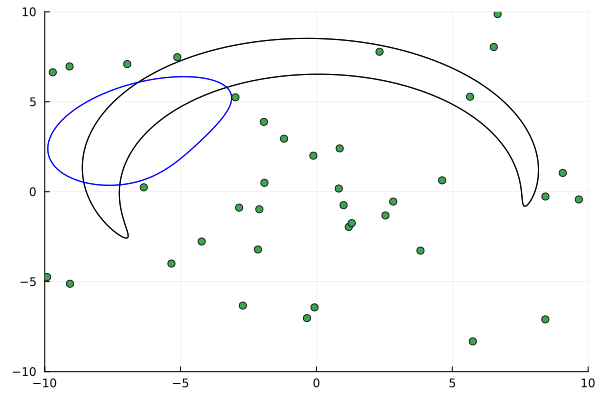

In [8]:
using Plots

function make_contour_plot(B::Polynomial, limits ::Tuple{Float64,Float64}, clr::String; x3_val=0.0,x4_val=0.0)
    x = range(limits[1], limits[2], length=500)
    y = range(limits[1], limits[2], length=500)
    my_fun(xa::Float64,ya::Float64) = B([xa, ya, x3_val, x4_val])
    z = @.my_fun(x', y)
    contour!(x, y, z,levels=[0.0, 0.0], color=clr, colorbar=false)
end

limits=(-10., 10.)
plot(xlims = limits, ylims = limits)
# make_contour_plot(g, limits,"red") 
make_contour_plot(B_1, limits, "black")
make_contour_plot(B_2, limits, "blue")

plot!([x1 for (x1,_) in test_pts], [x2 for (_, x2) in test_pts], seriestype=:scatter, labels=false)


In [9]:
using LaTeXStrings
function circleShape(x,y, r)
    θ = LinRange(0, 2*π, 500)
    x .+ r*cos.(θ), y .+ r*sin.(θ)
end
function plot_ics_region(limits::Tuple{Float64,Float64}, all_barriers::Vector{<:Polynomial}; δ = 0.5, x3_val=π/2,x4_val=0.)
    plot(xlims=limits, ylims=limits)
    rectangle(w, h, x, y) = Shape(x .+ [0,w,w,0], y .+ [0,0,h,h])
    for x in limits[1]:δ:limits[2]
        for y in limits[1]:δ:limits[2]
           if (any([ B(x, y, x3_val, x4_val) <= 0. for B in all_barriers]))
              plot!(rectangle(δ, δ, x-δ, y-δ), label=false, fill=:green, opacity=0.5,linecolor=:green)
           end
        end
    end
    plot!(circleShape(0,0,1.), seriestype =[:shape], lw=0.5, c=:black, linecolor=:black, legend=false, aspectratio=1  )
    plot!(xlims=limits, ylims=limits)
end

plot_ics_region (generic function with 1 method)

In [10]:
all_barriers = [B_1, B_2]

2-element Vector{Polynomial{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, Graded{LexOrder}, Float64}}:
 9.999999939578505 + 2.3731380136433575x₄ - 5.596268096202906x₃ + 0.43987083029967367x₂ - 0.009925967224653656x₁ + 0.3344054066772751x₄² - 0.5780154428649478x₃x₄ + 3.5455359882204807x₃² - 0.4128430795770978x₂x₄ - 0.06686196766493481x₂x₃ - 0.4221785950146134x₂² + 0.2657839330598222x₁x₄ + 0.00852600180110059x₁x₃ - 0.005832683123339427x₁x₂ - 0.32999732813540456x₁² + 0.023995914897590634x₄³ + 0.02231119569022775x₃x₄² + 0.05826568415249972x₃²x₄ + 1.1941506269498134x₃³ - 0.06438474156545733x₂x₄² + 0.17846108013843898x₂x₃x₄ + 0.10901264731736705x₂x₃² - 0.0725340911945776x₂²x₄ + 0.16534969352538936x₂²x₃ - 0.010830923710169024x₂³ + 0.03260868329698167x₁x₄² - 0.11254822316816634x₁x₃x₄ + 0.11628525149778172x₁x₃² + 0.005882449922006685x₁x₂x₄ + 0.004645043836101252x₁x₂x₃ + 0.0003067243898322592x₁x₂² - 0.04625709725158868x₁²x₄ + 0.12724892023124962x₁²x₃ - 0.008384996460977666x₁²

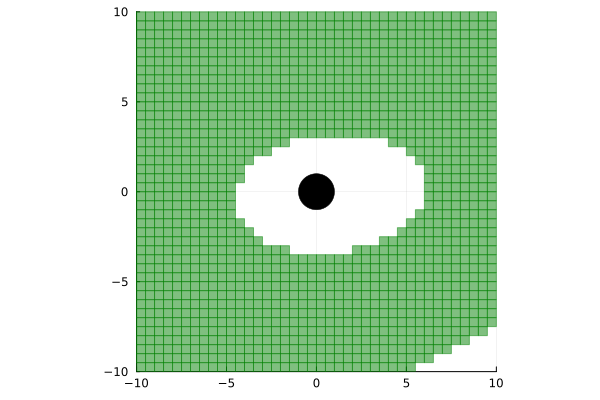

In [11]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=2.,x4_val=0)

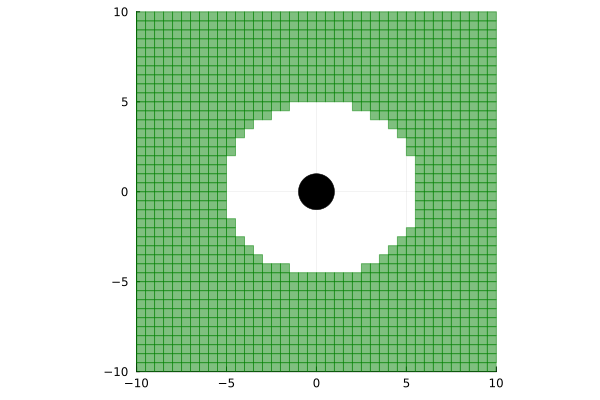

In [12]:
plot_ics_region((-10.0, 10.0), all_barriers; x3_val=-2.,x4_val=0)

[ Info: Saved animation to /Users/rameez/workspace/moving_obs_barrier/figures/repulsive_hybrid_dubins_moving_obstacle.gif


Simulation finished
minimum recentered barrier value = -524.485931264517
minimum true obstacle distance = 15.835886500244783
mean tracking error = 13.044971838992588
max tracking error = 23.926723430637633
number of barrier overrides = 25
Animation saved to figures/repulsive_hybrid_dubins_moving_obstacle.gif


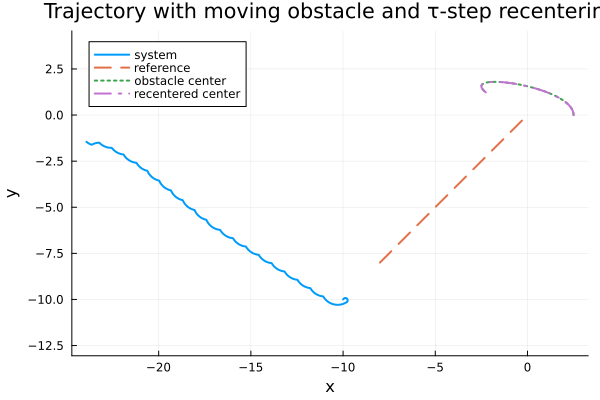

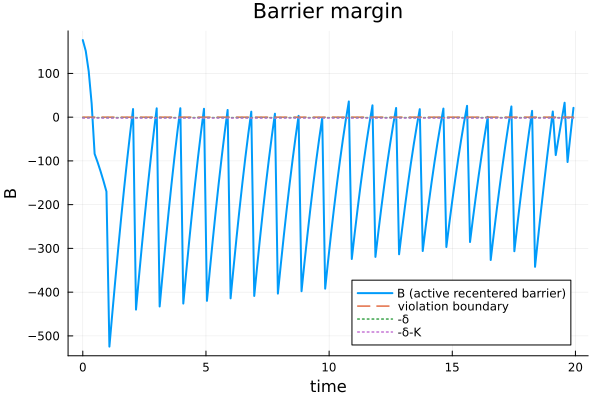

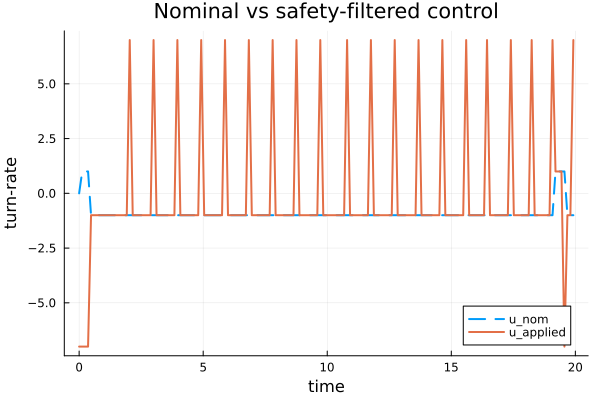

In [13]:
include("Repulsive_hybrid_dubins_recenter_fix.jl")
barrier_controls = [U[1][1], U[2][1]]
τ_steps_run = @isdefined(τ_steps) ? τ_steps : 1

res = run_repulsive_hybrid_dubins_demo(
    all_barriers;
    v,
    τ_steps=τ_steps_run,
    dt=τ,
    T=20.0,
    k_override=K,
    δ,
    barrier_controls=barrier_controls,
    umin=minimum(barrier_controls),
    umax=maximum(barrier_controls),
 )
display(res.p_traj); display(res.p_B); display(res.p_u)